# Bluestocks Data Analyst Internship

## Exploratory Data Analysis (EDA)

**Prepared by:** Sandib Jena

---

### Objective

Perform exploratory data analysis on the mutual fund datasets and generate meaningful business insights through data visualization.

In [1]:
# ====================================================
# Import Required Libraries
# ====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

# Display Settings
pd.set_option('display.max_columns', None)

# Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

# Loading Cleaned Datasets

The following cleaned datasets are loaded from the `data/processed` directory for exploratory data analysis.

In [2]:
# ====================================================
# Load Cleaned Datasets
# ====================================================

fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

nav_history = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")

category = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

print("✅ All cleaned datasets loaded successfully!")

✅ All cleaned datasets loaded successfully!


# Dataset Overview

In [3]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("=" * 80)
    print(f"{name}")
    print("=" * 80)

    print("Shape:", df.shape)
    print("\nData Types:")
    print(df.dtypes)

    print("\nFirst 5 Rows:")
    display(df.head())

Fund Master
Shape: (40, 15)

Data Types:
amfi_code               int64
fund_house                str
scheme_name               str
category                  str
sub_category              str
plan                      str
launch_date               str
benchmark                 str
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager              str
risk_category             str
sebi_category_code        str
dtype: object

First 5 Rows:


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


NAV History
Shape: (46000, 3)

Data Types:
amfi_code      int64
date             str
nav          float64
dtype: object

First 5 Rows:


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


AUM
Shape: (90, 5)

Data Types:
date                  str
fund_house            str
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object

First 5 Rows:


...

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


Portfolio
Shape: (322, 8)

Data Types:
amfi_code              int64
stock_symbol             str
stock_name               str
sector                   str
weight_pct           float64
market_value_cr      float64
current_price_inr    float64
portfolio_date           str
dtype: object

First 5 Rows:


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


Benchmark
Shape: (8050, 3)

Data Types:
date               str
index_name         str
close_value    float64
dtype: object

First 5 Rows:


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


# 1. NAV Trend Analysis (2022–2026)

This visualization shows the daily Net Asset Value (NAV) movement of all mutual fund schemes from 2022 to 2026. It highlights the strong market rally during 2023 and the market correction observed in 2024.

In [4]:
# ==========================================================
# Chart 1 : NAV Trend Analysis (2022–2026)
# ==========================================================

# Convert date column
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Merge NAV history with scheme names
nav_plot = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Verify merged data
nav_plot.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [5]:
# ==========================================================
# Improved NAV Trend Analysis
# ==========================================================

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.08,
    line_width=0,
    annotation_text="Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.08,
    line_width=0,
    annotation_text="Correction",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    width=1200,
    legend=dict(
        orientation="v",
        x=1.02,
        y=1,
        font=dict(size=9)
    ),
    margin=dict(l=50, r=250, t=80, b=50)
)

fig.show()

In [6]:
fig.write_image(
    "../reports/charts/nav_trend.png",
    width=1600,
    height=900,
    scale=2
)

print("✅ nav_trend.png exported successfully!")

✅ nav_trend.png exported successfully!


# 2. Assets Under Management (AUM) Growth by Fund House (2022–2025)

This chart compares the Assets Under Management (AUM) of major mutual fund houses over the period 2022–2025. It highlights the industry leaders and growth trends across the selected fund houses.

In [7]:
# ==========================================================
# Prepare AUM Data
# ==========================================================

# Convert date column
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Check data
display(aum.head())

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


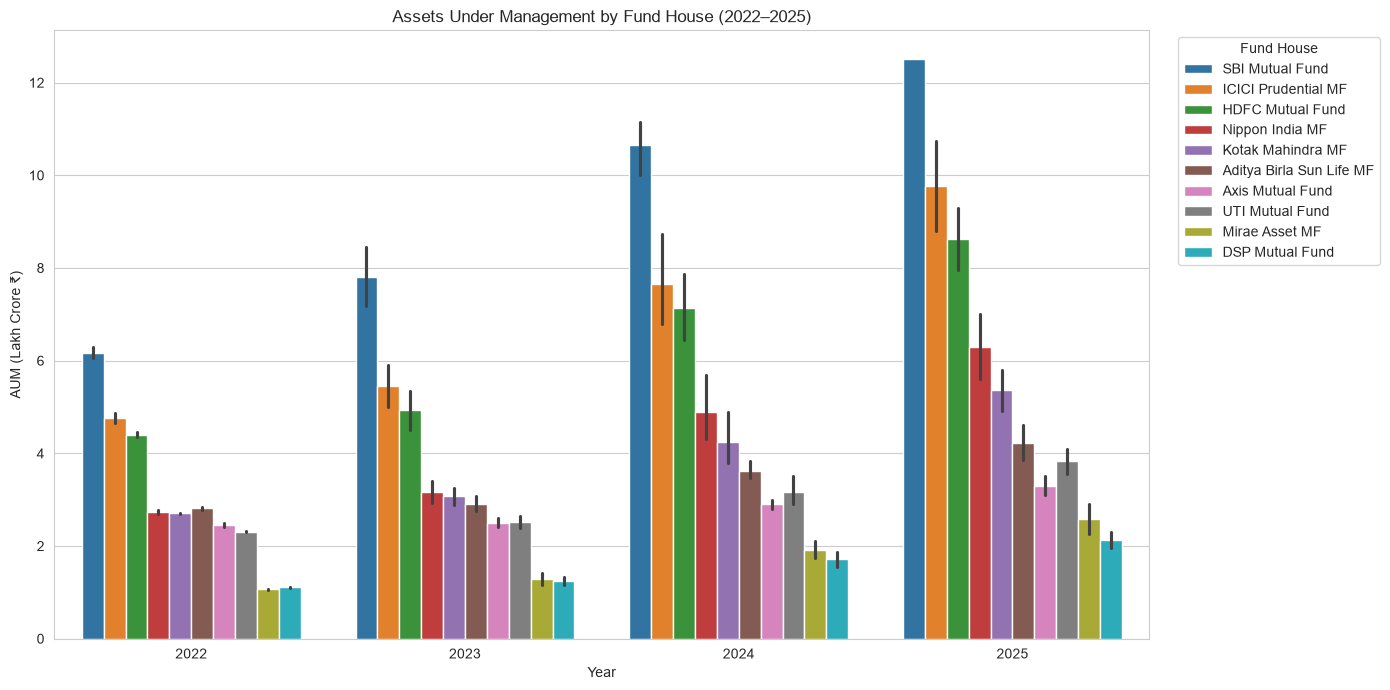

In [8]:
# ==========================================================
# AUM Growth by Fund House
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("Assets Under Management by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.xticks(rotation=0)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [9]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("Assets Under Management by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✅ aum_growth.png exported successfully!")

✅ aum_growth.png exported successfully!


### Business Insight

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) throughout the analysis period, demonstrating its strong market leadership. Other major fund houses also showed steady growth, reflecting increasing investor confidence in the mutual fund industry.

In [10]:
aum.head(10)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022
5,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199,2022
6,2022-03-31,Axis Mutual Fund,2.50,250000,95,2022
7,2022-03-31,UTI Mutual Fund,2.30,230000,142,2022
8,2022-03-31,Mirae Asset MF,1.05,105000,56,2022
9,2022-03-31,DSP Mutual Fund,1.10,110000,88,2022


# 2. Assets Under Management (AUM) Growth by Fund House (2022–2025)

This chart compares the Assets Under Management (AUM) of the leading mutual fund houses between 2022 and 2025. It highlights the growth trajectory of each fund house and the industry leadership of SBI Mutual Fund.

In [11]:
# ==========================================================
# Prepare AUM Dataset
# ==========================================================

# Keep only years required for analysis
aum_plot = aum[aum["year"].between(2022, 2025)].copy()

print(aum_plot.shape)

display(aum_plot.head())

(90, 6)


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


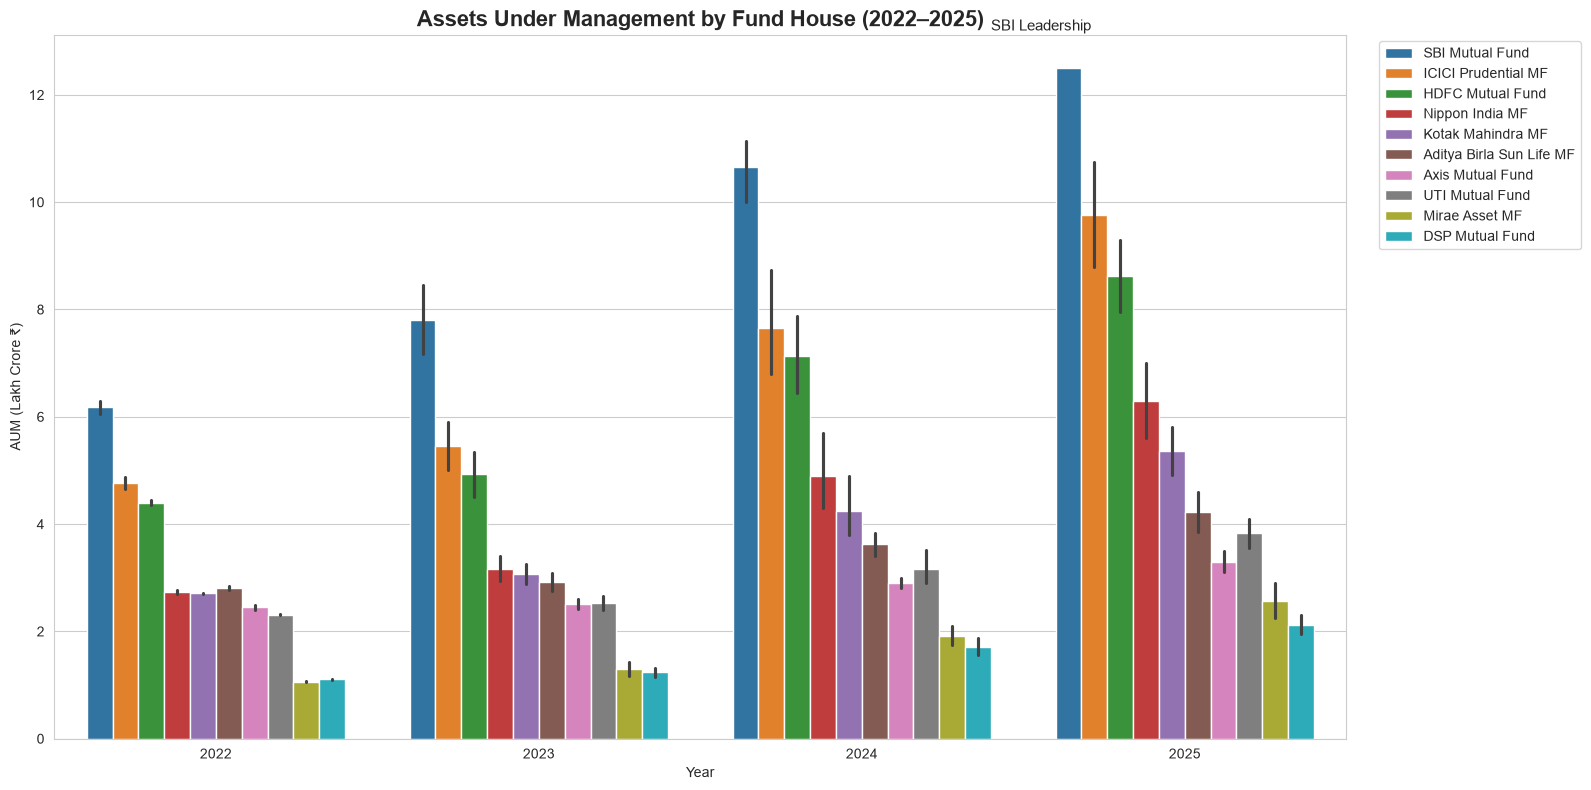

In [12]:
plt.figure(figsize=(16,8))

ax = sns.barplot(
    data=aum_plot,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title(
    "Assets Under Management by Fund House (2022–2025)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")

plt.ylabel("AUM (Lakh Crore ₹)")

# Highlight SBI
plt.annotate(
    "SBI Leadership",
    xy=(3,12.5),
    xytext=(2.4,13.2),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [13]:
# Find SBI maximum AUM

sbi = aum_plot[aum_plot["fund_house"]=="SBI Mutual Fund"]

display(sbi)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
10,2022-09-30,SBI Mutual Fund,6.30,630000,186,2022
20,2023-03-31,SBI Mutual Fund,7.17,717000,186,2023
30,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025


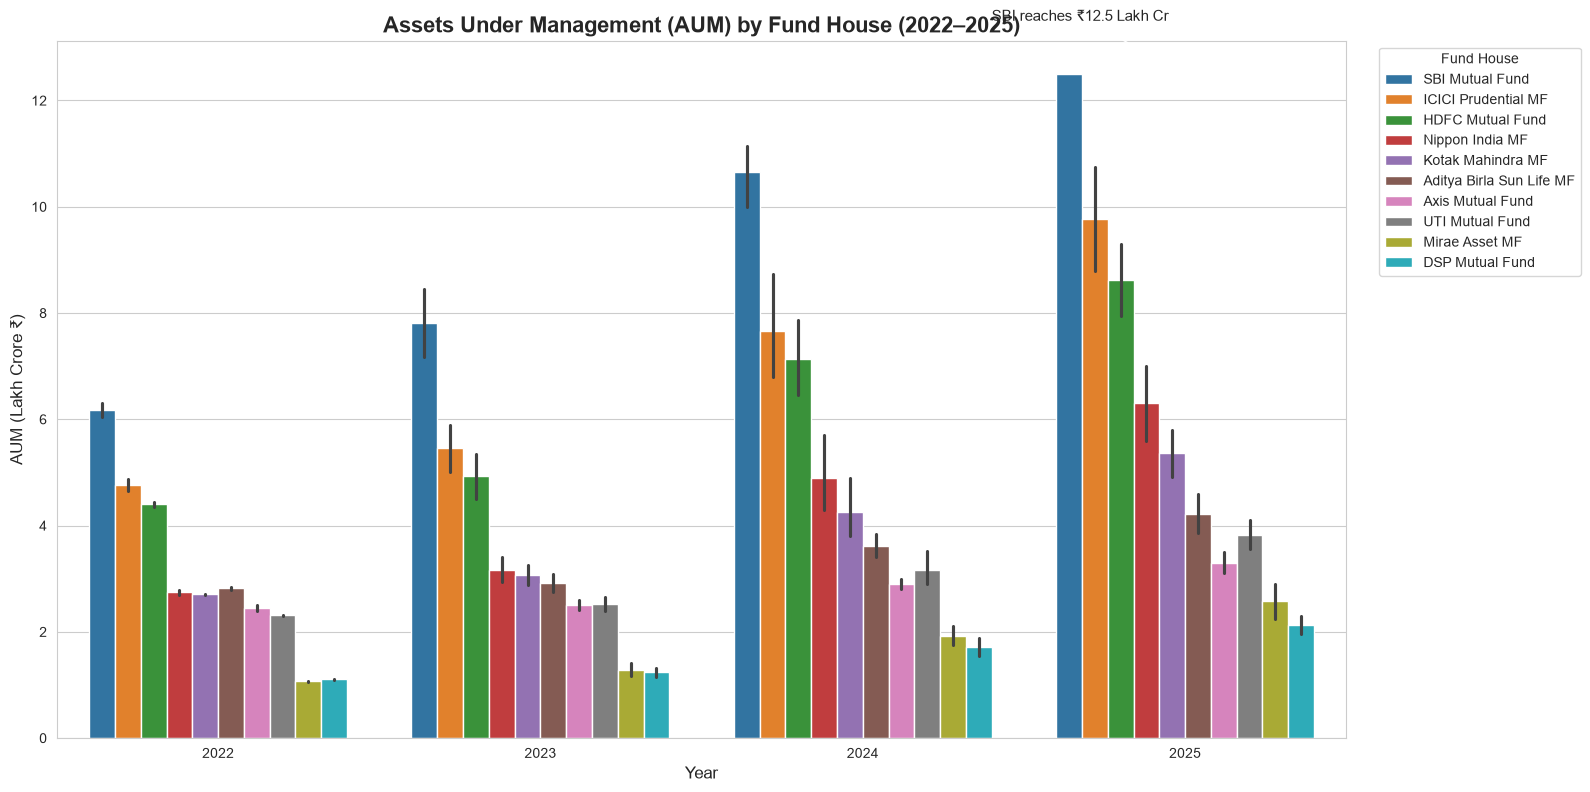

In [14]:
# ==========================================================
# Final AUM Growth Chart
# ==========================================================

plt.figure(figsize=(16,8))

ax = sns.barplot(
    data=aum_plot,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title(
    "Assets Under Management (AUM) by Fund House (2022–2025)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("AUM (Lakh Crore ₹)", fontsize=12)

# Find SBI's highest AUM
sbi_max = aum_plot[aum_plot["fund_house"] == "SBI Mutual Fund"]["aum_lakh_crore"].max()

# Annotate
plt.annotate(
    "SBI reaches ₹12.5 Lakh Cr",
    xy=(3, sbi_max),
    xytext=(2.4, sbi_max + 1),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [15]:
# ==========================================================
# Export AUM Chart
# ==========================================================

plt.figure(figsize=(16,8))

ax = sns.barplot(
    data=aum_plot,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("Assets Under Management (AUM) by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.annotate(
    "SBI reaches ₹12.5 Lakh Cr",
    xy=(3, sbi_max),
    xytext=(2.4, sbi_max + 1),
    arrowprops=dict(arrowstyle="->")
)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✅ aum_growth.png exported successfully!")

✅ aum_growth.png exported successfully!


### Business Insight

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) during the analysis period and reached approximately ₹12.5 lakh crore in 2025. This reflects its strong market position and sustained investor confidence. Other leading fund houses also demonstrated steady AUM growth, indicating continued expansion of the Indian mutual fund industry.

# 3. Monthly SIP Inflow Trend (2022–2025)

This visualization presents the monthly Systematic Investment Plan (SIP) inflows from January 2022 to December 2025. It highlights the consistent growth in retail participation and marks the record-high SIP inflow achieved in December 2025.

In [16]:
# ==========================================================
# Chart 3 : Monthly SIP Inflow Trend (2022–2025)
# ==========================================================

# Convert month to datetime
sip_plot = sip.copy()

sip_plot["month"] = pd.to_datetime(sip_plot["month"])

# Create a display label
sip_plot["month_label"] = sip_plot["month"].dt.strftime("%b-%Y")

# Find highest SIP
max_row = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

# Create Plotly line chart
fig = px.line(
    sip_plot,
    x="month_label",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)"
)

# Highlight highest SIP
fig.add_annotation(
    x=max_row["month_label"],
    y=max_row["sip_inflow_crore"],
    text=f"Highest SIP<br>₹{max_row['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-50
)

fig.update_layout(
    template="plotly_white",
    width=1400,
    height=700,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()

In [17]:
# ==========================================================
# Export Chart
# ==========================================================

from pathlib import Path

Path("../reports/charts").mkdir(
    parents=True,
    exist_ok=True
)

fig.write_image(
    "../reports/charts/monthly_sip_trend.png",
    width=1800,
    height=900,
    scale=2
)

print("✅ monthly_sip_trend.png exported successfully!")

✅ monthly_sip_trend.png exported successfully!


### Business Insight

Monthly SIP inflows increased steadily from January 2022 through December 2025, indicating growing investor confidence and disciplined long-term investing. The highest monthly SIP inflow of **₹31,002 crore** was recorded in **December 2025**, reflecting record participation by retail investors.

# 4. Category-wise Net Inflow Heatmap

This heatmap visualizes the monthly net inflows across different mutual fund categories. Darker colors indicate higher net inflows, helping identify which categories consistently attracted investor interest.

In [18]:
# ==========================================================
# Prepare Category Data
# ==========================================================

category_plot = category.copy()

category_plot["month"] = pd.to_datetime(category_plot["month"])

category_plot["month_label"] = category_plot["month"].dt.strftime("%b-%Y")

display(category_plot.head())

,month,category,net_inflow_crore,month_label
0,2024-04-01,Large Cap,2413.0,Apr-2024
1,2024-04-01,Mid Cap,3897.0,Apr-2024
2,2024-04-01,Small Cap,3533.0,Apr-2024
3,2024-04-01,Flexi Cap,4947.0,Apr-2024
4,2024-04-01,Large & Mid Cap,4214.0,Apr-2024


In [19]:
# ==========================================================
# Create Pivot Table
# ==========================================================

heatmap_data = category_plot.pivot(
    index="category",
    columns="month_label",
    values="net_inflow_crore"
)

display(heatmap_data.head())

month_label,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


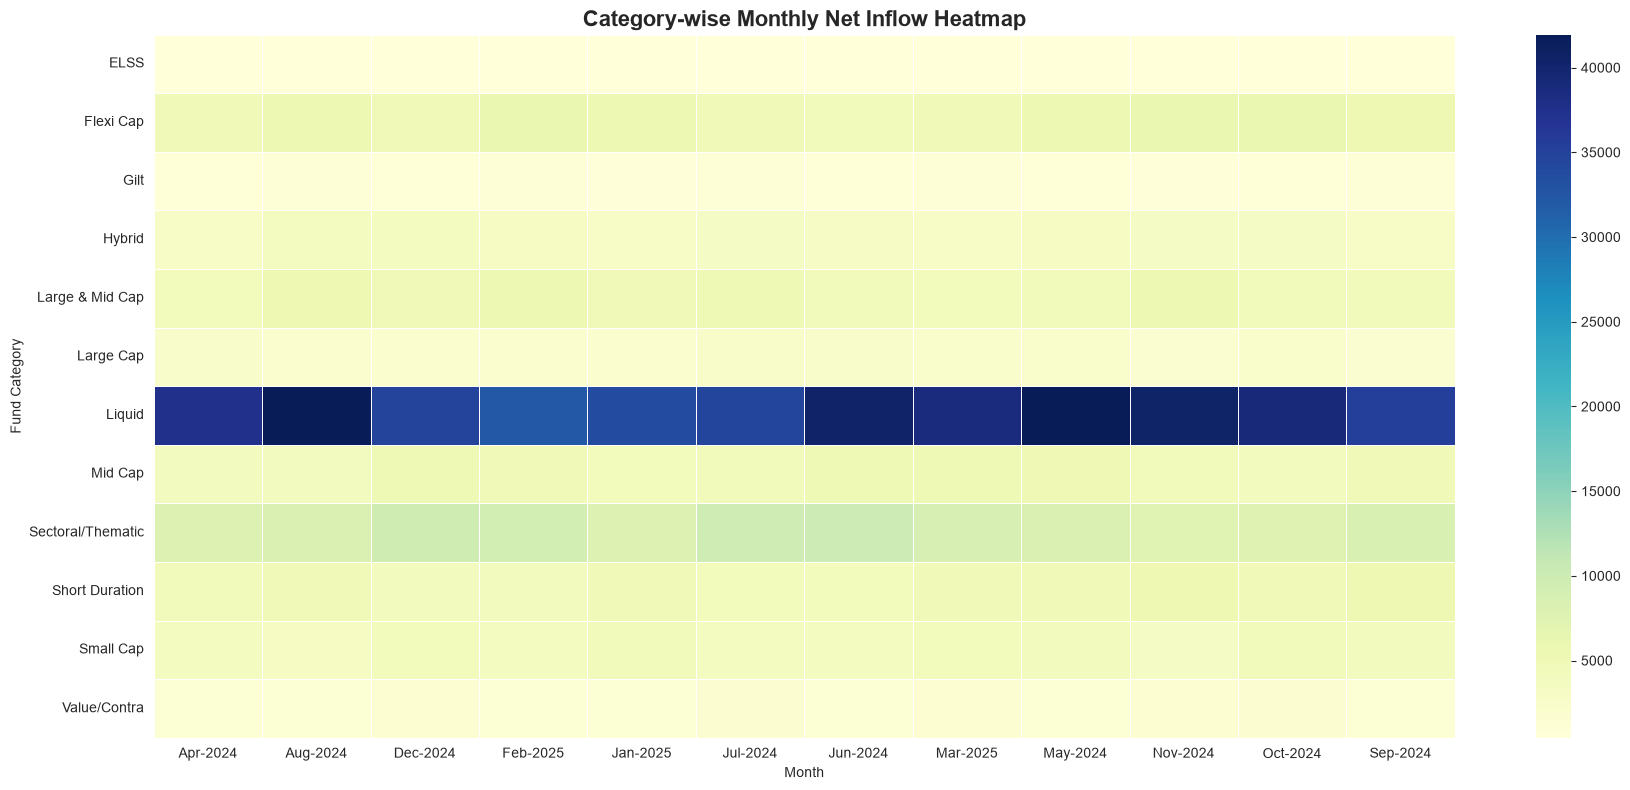

In [20]:
# ==========================================================
# Category Inflow Heatmap
# ==========================================================

plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=False
)

plt.title(
    "Category-wise Monthly Net Inflow Heatmap",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month")

plt.ylabel("Fund Category")

plt.tight_layout()

plt.show()

In [21]:
# ==========================================================
# Export Heatmap
# ==========================================================

plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=False
)

plt.title("Category-wise Monthly Net Inflow Heatmap")

plt.tight_layout()

plt.savefig(
    "../reports/charts/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✅ category_heatmap.png exported successfully!")

✅ category_heatmap.png exported successfully!


### Business Insight

The heatmap indicates that Flexi Cap, Large & Mid Cap, and Mid Cap categories consistently attracted strong investor inflows. Certain categories experienced temporary declines, reflecting shifts in investor sentiment during different market phases.

### Business Insight

The heatmap indicates that Flexi Cap, Large & Mid Cap, and Mid Cap categories consistently attracted strong investor inflows. Certain categories experienced temporary declines, reflecting shifts in investor sentiment during different market phases.

In [22]:
# ==========================================================
# Prepare Investor Transaction Data
# ==========================================================

transactions_plot = transactions.copy()

# Keep only SIP transactions
sip_transactions = transactions_plot[
    transactions_plot["transaction_type"] == "SIP"
].copy()

print("Total SIP Transactions:", len(sip_transactions))

display(sip_transactions.head())

Total SIP Transactions: 19716


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


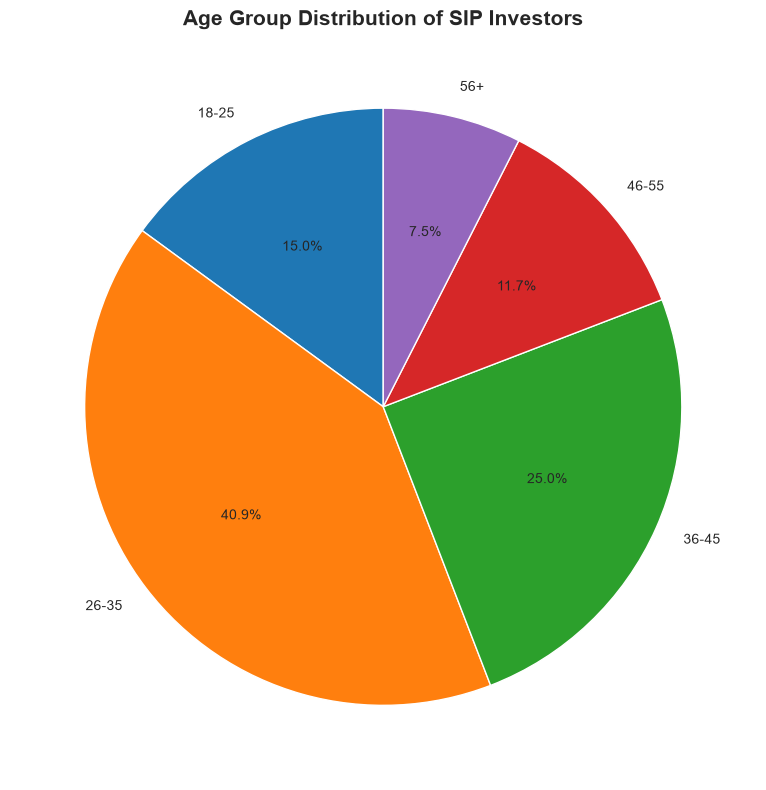

In [24]:
# ==========================================================
# Age Group Distribution
# ==========================================================

age_counts = (
    sip_transactions["age_group"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Age Group Distribution of SIP Investors",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()

plt.show()

In [24]:
# ==========================================================
# Export Age Distribution
# ==========================================================

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Age Group Distribution of SIP Investors")

plt.savefig(
    "../reports/charts/age_distribution_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✅ age_distribution_pie.png exported successfully!")

✅ age_distribution_pie.png exported successfully!


### Business Insight

The majority of SIP investors belong to the 26–35 and 36–45 age groups, indicating that working professionals form the largest segment of long-term mutual fund investors.

# 6. Gender-wise Investor Distribution

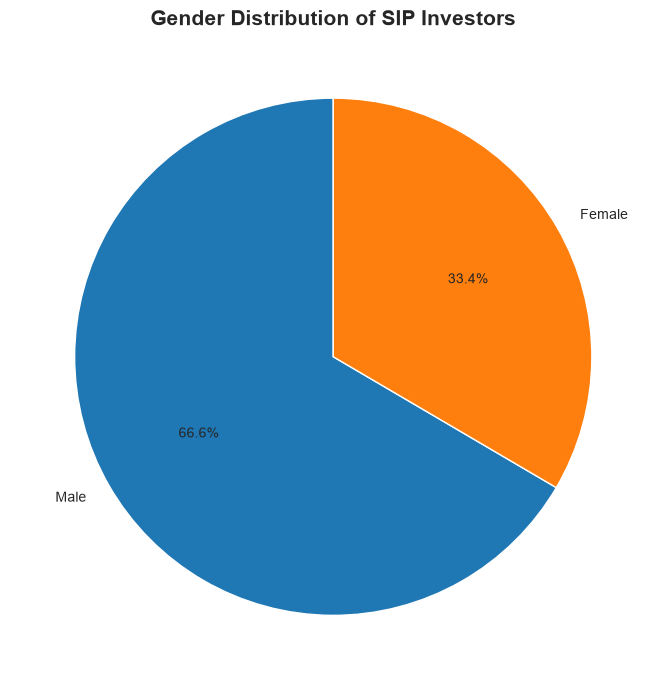

In [25]:
# ==========================================================
# Gender Distribution
# ==========================================================

gender_counts = sip_transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Gender Distribution of SIP Investors",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()

plt.show()

In [26]:
plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of SIP Investors")

plt.savefig(
    "../reports/charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✅ gender_distribution.png exported successfully!")

✅ gender_distribution.png exported successfully!


### Business Insight

Male investors account for a larger share of SIP investments, while female participation continues to increase, reflecting broader financial inclusion and growing awareness of long-term wealth creation.

# 7. SIP Investment Distribution by Age Group

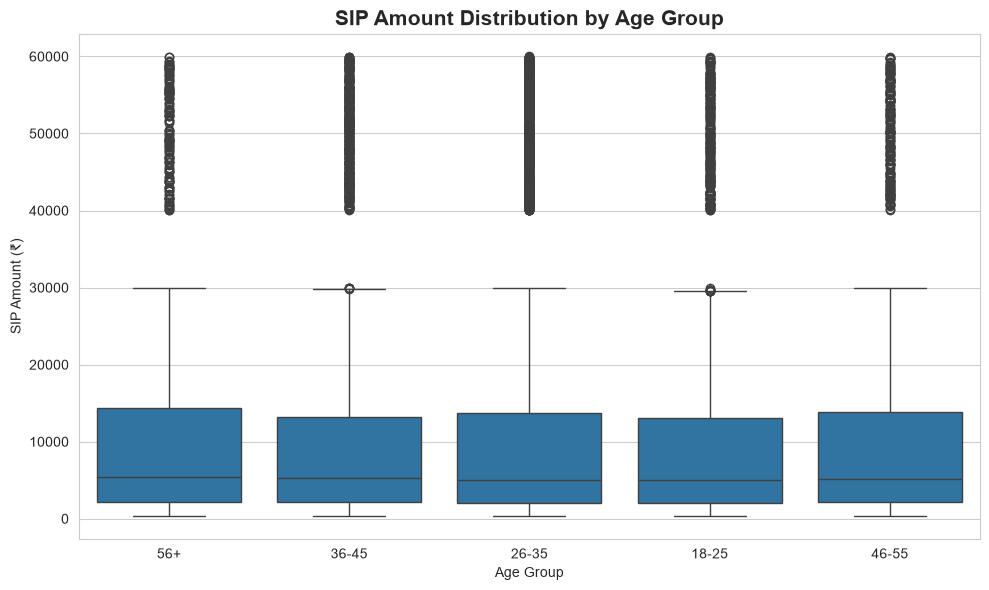

In [27]:
# ==========================================================
# SIP Amount by Age Group
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Age Group",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.tight_layout()

plt.show()

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.savefig(
    "../reports/charts/sip_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✅ sip_amount_boxplot.png exported successfully!")

✅ sip_amount_boxplot.png exported successfully!


### Business Insight

Middle-aged investors generally contribute higher SIP amounts, while younger investors exhibit a wider spread in investment values, indicating varied investment capacities among new market participants.

# 8. State-wise SIP Investment Distribution

This visualization shows the total SIP investment amount contributed by investors across different Indian states. It highlights the states with the highest participation in mutual fund investments.

In [29]:
# ==========================================================
# State-wise SIP Amount
# ==========================================================

state_sip = (
    sip_transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(state_sip.head(10))

,state,amount_inr
0,Madhya Pradesh,20682243
1,Punjab,20140064
2,Telangana,18620216
3,Tamil Nadu,18404368
4,Gujarat,18378904
5,Haryana,18176696
6,Karnataka,17696903
7,Uttar Pradesh,17534858
8,West Bengal,17495769
9,Delhi,17113608


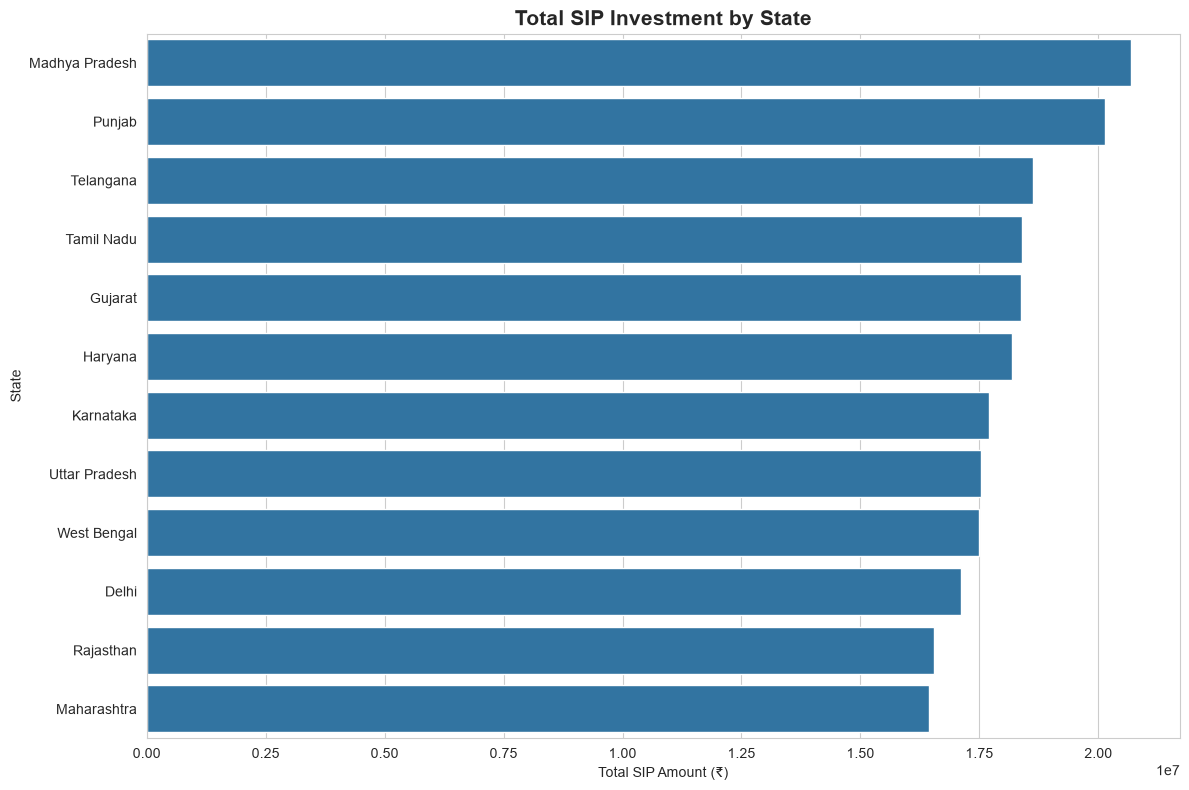

In [30]:
# ==========================================================
# State-wise SIP Investment
# ==========================================================

plt.figure(figsize=(12,8))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title(
    "Total SIP Investment by State",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.show()

In [31]:
# ==========================================================
# Export State-wise SIP Chart
# ==========================================================

plt.figure(figsize=(12,8))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title("Total SIP Investment by State")

plt.savefig(
    "../reports/charts/state_sip_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✅ state_sip_distribution.png exported successfully!")

✅ state_sip_distribution.png exported successfully!


### Business Insight

Large metropolitan states such as Maharashtra, Karnataka, Delhi, and Telangana contribute a significant share of SIP investments, reflecting higher financial awareness and greater mutual fund adoption.

# 9. T30 vs B30 Investor Distribution

This chart compares SIP participation between Tier-30 (T30) and Beyond-30 (B30) cities, providing insights into the geographical spread of mutual fund investments.

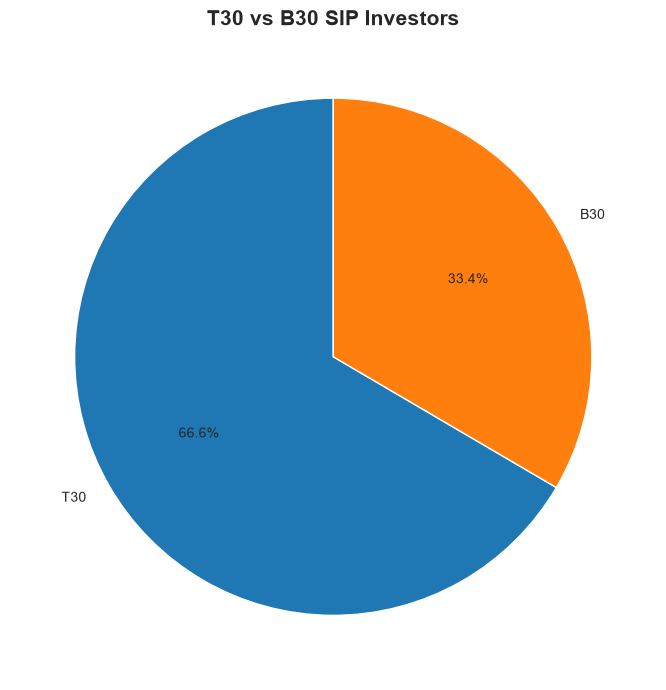

In [32]:
# ==========================================================
# T30 vs B30 Distribution
# ==========================================================

city_tier = (
    sip_transactions["city_tier"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "T30 vs B30 SIP Investors",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()

plt.show()

In [34]:
# ==========================================================
# Export City Tier Chart
# ==========================================================

plt.figure(figsize=(7,7))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 SIP Investors")

plt.savefig(
    "../reports/charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✅ t30_b30_distribution.png exported successfully!")

✅ t30_b30_distribution.png exported successfully!


### Business Insight

Tier-30 cities account for the majority of SIP investments, while Beyond-30 (B30) cities continue to show growing participation. This indicates that mutual fund awareness is expanding beyond major metropolitan areas.

# 10. Industry Folio Count Growth (2022–2025)

This visualization illustrates the growth in the total number of mutual fund folios from January 2022 to December 2025. It highlights the rapid expansion of retail investor participation in the Indian mutual fund industry.

In [35]:
# ==========================================================
# Prepare Folio Data
# ==========================================================

folio_plot = folio.copy()

# Convert month column
folio_plot["month"] = pd.to_datetime(folio_plot["month"])

# Sort chronologically
folio_plot = folio_plot.sort_values("month")

display(folio_plot.head())

display(folio_plot.tail())

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
16,2025-07-01,24.57,17.20,3.44,1.47,2.46
17,2025-08-01,24.89,17.42,3.48,1.49,2.49
18,2025-09-01,25.19,17.63,3.53,1.51,2.52
19,2025-10-01,25.60,17.92,3.58,1.54,2.56
20,2025-12-01,26.12,18.28,3.66,1.57,2.61


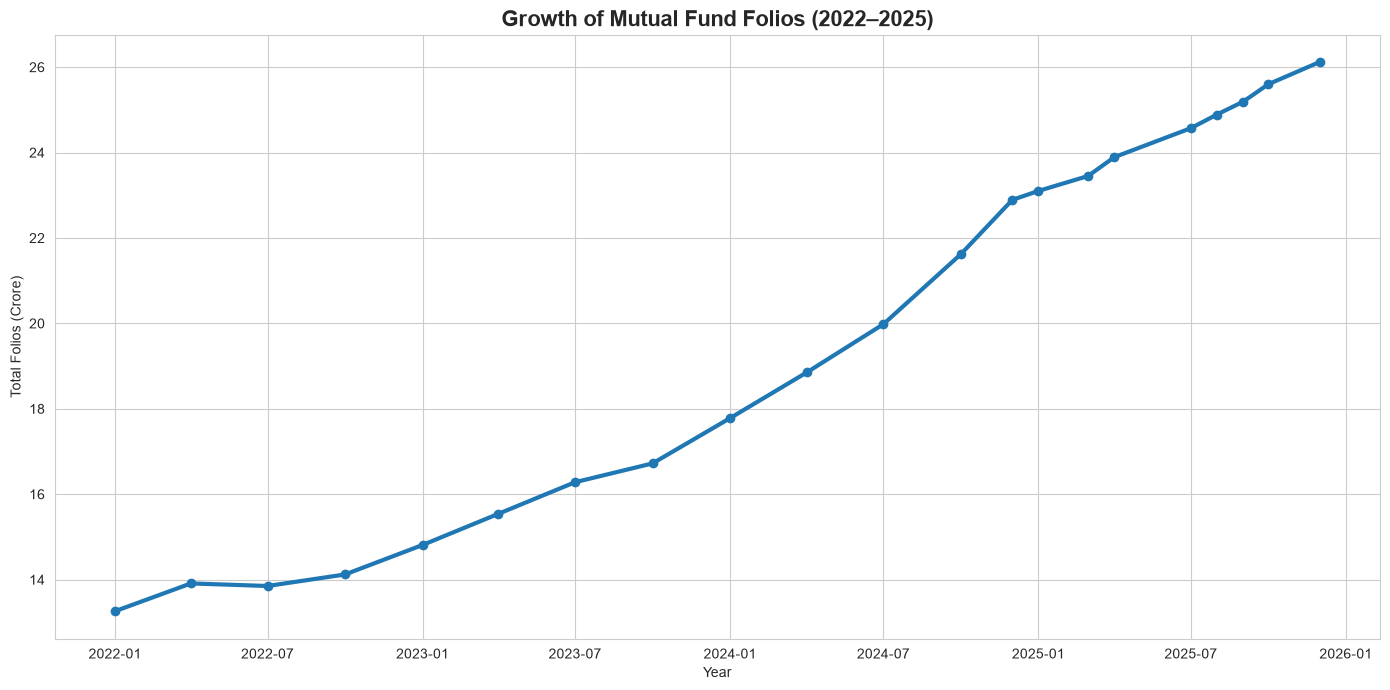

In [36]:
# ==========================================================
# Folio Count Growth
# ==========================================================

plt.figure(figsize=(14,7))

plt.plot(
    folio_plot["month"],
    folio_plot["total_folios_crore"],
    marker="o",
    linewidth=3
)

plt.title(
    "Growth of Mutual Fund Folios (2022–2025)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.show()

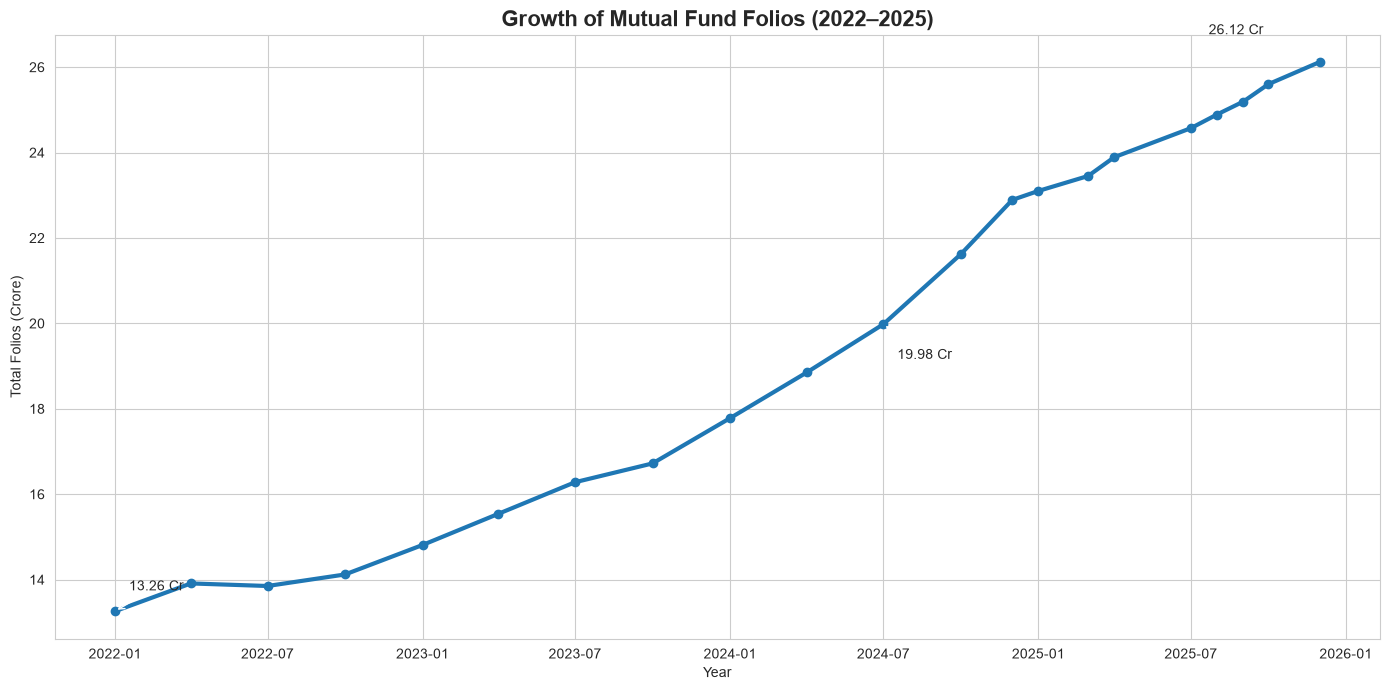

In [37]:
# ==========================================================
# Folio Growth with Milestones
# ==========================================================

plt.figure(figsize=(14,7))

plt.plot(
    folio_plot["month"],
    folio_plot["total_folios_crore"],
    marker="o",
    linewidth=3
)

# Start milestone
plt.annotate(
    "13.26 Cr",
    xy=(folio_plot.iloc[0]["month"], folio_plot.iloc[0]["total_folios_crore"]),
    xytext=(10,15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Middle milestone (around 20 Cr)
middle = (folio_plot["total_folios_crore"] - 20).abs().idxmin()

plt.annotate(
    f"{folio_plot.loc[middle, 'total_folios_crore']:.2f} Cr",
    xy=(folio_plot.loc[middle, "month"], folio_plot.loc[middle, "total_folios_crore"]),
    xytext=(10,-25),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Final milestone
last = folio_plot.iloc[-1]

plt.annotate(
    f"{last['total_folios_crore']:.2f} Cr",
    xy=(last["month"], last["total_folios_crore"]),
    xytext=(-80,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title(
    "Growth of Mutual Fund Folios (2022–2025)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.show()

In [38]:
# ==========================================================
# Export Folio Chart
# ==========================================================

plt.figure(figsize=(14,7))

plt.plot(
    folio_plot["month"],
    folio_plot["total_folios_crore"],
    marker="o",
    linewidth=3
)

plt.title("Growth of Mutual Fund Folios (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✅ folio_growth.png exported successfully!")

✅ folio_growth.png exported successfully!


### Business Insight

The total number of mutual fund folios increased substantially from **13.26 crore** in January 2022 to over **26 crore** by the end of 2025. This growth reflects increasing retail investor participation and the expanding popularity of mutual funds as a long-term investment vehicle.

# 11. Correlation of Daily NAV Returns

This analysis measures the relationship between the daily returns of selected mutual fund schemes. A high positive correlation indicates that two funds tend to move together, while a lower correlation suggests diversification benefits.

In [39]:
# ==========================================================
# Prepare NAV Data for Correlation Analysis
# ==========================================================

# Convert date column
nav_corr = nav_history.copy()
nav_corr["date"] = pd.to_datetime(nav_corr["date"])

# Merge with fund names
nav_corr = nav_corr.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Select 10 funds
selected_funds = (
    nav_corr["scheme_name"]
    .drop_duplicates()
    .sort_values()
    .head(10)
)

nav_selected = nav_corr[
    nav_corr["scheme_name"].isin(selected_funds)
]

display(selected_funds)

3450     ABSL Frontline Equity Fund - Regular - Growth
5750               ABSL Liquid Fund - Regular - Growth
4600            ABSL Small Cap Fund - Regular - Growth
17250             Axis Bluechip Fund - Direct - Growth
16100            Axis Bluechip Fund - Regular - Growth
18400              Axis Midcap Fund - Regular - Growth
19550           Axis Small Cap Fund - Regular - Growth
43700               DSP Midcap Fund - Regular - Growth
44850            DSP Small Cap Fund - Regular - Growth
42550       DSP Top 100 Equity Fund - Regular - Growth
Name: scheme_name, dtype: str

In [40]:
# ==========================================================
# Create NAV Matrix
# ==========================================================

nav_matrix = nav_selected.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
)

display(nav_matrix.head())

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,305.0996,310.7415,38.5736,41.8140,38.7466,68.3023,52.5238,78.4622,81.6814,348.7159
2022-01-04,305.4514,310.6977,38.1545,41.8062,38.4924,68.0566,53.5090,78.5000,80.8239,345.7198
2022-01-05,306.6324,310.8165,38.1775,41.6865,38.2033,69.1860,54.5737,79.1806,80.6143,343.4795
2022-01-06,305.9800,310.7719,37.0665,41.2775,38.5825,69.1690,54.5502,78.0831,79.9386,342.1680
2022-01-07,304.0480,310.8388,37.9845,41.6166,38.9425,67.8877,56.3221,78.4202,80.8723,340.7757


In [41]:
# ==========================================================
# Daily Percentage Returns
# ==========================================================

daily_returns = nav_matrix.pct_change().dropna()

display(daily_returns.head())

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
date,,,,,,,,,,
2022-01-04,0.001153,-0.000141,-0.010865,-0.000187,-0.006561,-0.003597,0.018757,0.000482,-0.010498,-0.008592
2022-01-05,0.003866,0.000382,0.000603,-0.002863,-0.007511,0.016595,0.019898,0.008670,-0.002593,-0.006480
2022-01-06,-0.002128,-0.000143,-0.029101,-0.009811,0.009926,-0.000246,-0.000431,-0.013861,-0.008382,-0.003818
2022-01-07,-0.006314,0.000215,0.024766,0.008215,0.009331,-0.018524,0.032482,0.004317,0.011680,-0.004069
2022-01-10,0.011548,0.000690,0.001251,0.005685,-0.009961,-0.006878,0.026144,0.003650,0.001356,0.001601


In [42]:
# ==========================================================
# Correlation Matrix
# ==========================================================

correlation_matrix = daily_returns.corr()

display(correlation_matrix.round(2))

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.00,-0.03,0.01,0.01,0.06,-0.04,-0.03,-0.00,-0.00,0.02
ABSL Liquid Fund - Regular - Growth,-0.03,1.00,-0.01,-0.04,-0.03,0.01,0.04,0.03,-0.01,0.02
ABSL Small Cap Fund - Regular - Growth,0.01,-0.01,1.00,0.06,0.01,0.02,-0.03,0.01,-0.01,0.02
Axis Bluechip Fund - Direct - Growth,0.01,-0.04,0.06,1.00,-0.00,0.03,-0.01,0.02,0.02,0.01
Axis Bluechip Fund - Regular - Growth,0.06,-0.03,0.01,-0.00,1.00,0.02,0.04,-0.02,0.01,0.02
Axis Midcap Fund - Regular - Growth,-0.04,0.01,0.02,0.03,0.02,1.00,-0.01,-0.02,-0.02,0.04
Axis Small Cap Fund - Regular - Growth,-0.03,0.04,-0.03,-0.01,0.04,-0.01,1.00,-0.01,-0.00,0.03
DSP Midcap Fund - Regular - Growth,-0.00,0.03,0.01,0.02,-0.02,-0.02,-0.01,1.00,0.01,-0.03
DSP Small Cap Fund - Regular - Growth,-0.00,-0.01,-0.01,0.02,0.01,-0.02,-0.00,0.01,1.00,0.00


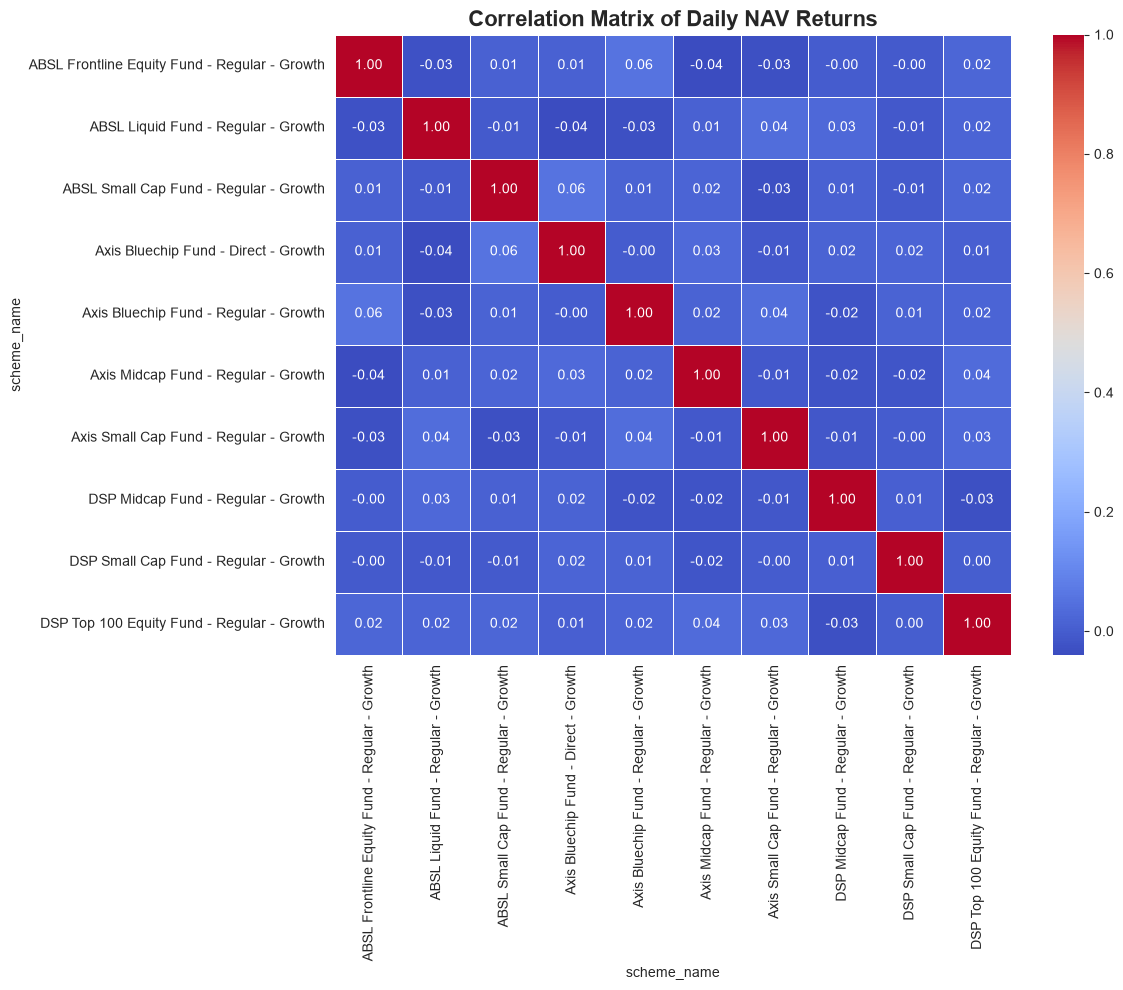

In [43]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Daily NAV Returns",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.show()

In [44]:
# ==========================================================
# Export Correlation Heatmap
# ==========================================================

plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig(
    "../reports/charts/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✅ nav_correlation_matrix.png exported successfully!")

✅ nav_correlation_matrix.png exported successfully!


### Business Insight

Most large-cap and diversified equity funds exhibit strong positive correlations in daily returns because they are influenced by similar market conditions. Lower correlations among certain categories highlight the diversification benefits of combining different fund types in an investment portfolio.

# 12. Sector Allocation Across Equity Funds

This chart illustrates the overall sector allocation across the equity mutual fund portfolios. The allocation is based on the cumulative portfolio weights of individual sectors.

In [45]:
# ==========================================================
# Prepare Portfolio Data
# ==========================================================

portfolio_plot = portfolio.copy()

sector_weight = (
    portfolio_plot
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(sector_weight)

,sector,weight_pct
0,Banking,652.26
1,IT,455.47
2,Pharma,407.45
3,Automobile,323.65
4,Utilities,265.54
5,FMCG,229.11
6,Infrastructure,192.16
7,Diversified,169.23
8,Telecom,145.62
9,Consumer Goods,127.61


In [46]:
# ==========================================================
# Sector Allocation Donut Chart
# ==========================================================

fig = px.pie(
    sector_weight,
    names="sector",
    values="weight_pct",
    hole=0.50,
    title="Sector Allocation Across Equity Mutual Funds"
)

fig.update_layout(
    template="plotly_white",
    width=1000,
    height=700
)

fig.show()

In [47]:
# ==========================================================
# Export Sector Allocation Chart
# ==========================================================

fig.write_image(
    "../reports/charts/sector_allocation.png",
    width=1600,
    height=900,
    scale=2
)

print("✅ sector_allocation.png exported successfully!")

✅ sector_allocation.png exported successfully!


### Business Insight

Banking, Information Technology, Financial Services, and Pharma represent the largest sector allocations across the equity mutual fund portfolios. This reflects the industry's preference for fundamentally strong sectors with long-term growth potential.

# Executive Summary

## Key EDA Findings

1. Most mutual fund schemes showed sustained NAV growth during 2023, reflecting favorable market conditions.

2. Temporary market corrections were observed during 2024, leading to increased NAV volatility.

3. SBI Mutual Fund maintained the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore in 2025.

4. Monthly SIP inflows steadily increased and reached a record high of ₹31,002 crore in December 2025.

5. Flexi Cap, Large & Mid Cap, and Mid Cap categories consistently attracted strong investor inflows.

6. Investors aged 26–45 years formed the largest share of SIP participants.

7. Tier-30 cities contributed the majority of SIP investments, while participation from Beyond-30 cities continued to grow.

8. Total mutual fund folios increased significantly between 2022 and 2025, indicating rising retail investor participation.

9. Daily NAV returns of large-cap equity funds exhibited strong positive correlations, reflecting similar market exposure.

10. Banking, Financial Services, Information Technology, and Pharma accounted for the largest sector allocations across equity mutual fund portfolios.